# 02 — Exploratory Data Analysis: Phase A — Data Integrity and Split Validation

This notebook documents **Phase A** of the EDA for the MIT-BIH ECG heartbeat dataset, building on the initial data loading and visual inspection performed in `01_data_loading.ipynb` (which is not modified here).

**Phase A objective:** before any preprocessing or modeling decision is made, verify that the dataset itself — its train/test split, its uniqueness, and its value ranges — is trustworthy.

Each analysis below follows the same structure:

> **Scientific question → Analysis → Result → Interpretation → Downstream implication**

**Scope of this notebook:**
- A1 — Train/Test Class Distribution and Split Structure
- A2 — Duplicate and Leakage Screening
- A3 — Value Range and Data Integrity

**Explicitly out of scope for this notebook** (deferred to the next EDA phase): zero-padding / effective signal length analysis, any preprocessing, and any machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.width", 120)

train_df = pd.read_csv("../data/raw/mitbih_train.csv", header=None)
test_df = pd.read_csv("../data/raw/mitbih_test.csv", header=None)

label_col = train_df.shape[1] - 1
feature_cols = list(range(label_col))

class_labels = {
    0.0: "Normal",
    1.0: "Supraventricular ectopic beat",
    2.0: "Ventricular ectopic beat",
    3.0: "Fusion beat",
    4.0: "Unknown beat",
}

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")

Train shape: (87554, 188)
Test shape:  (21892, 188)


## Phase A1 — Train/Test Class Distribution and Split Structure

**Objective:** Determine whether the provided train/test split preserves the class distribution of the full dataset, and whether row ordering within each file could bias any future sampling or cross-validation scheme.

**Scientific question:** Is the train/test split stratified by class, and is the row order inside each CSV randomized or structured?

**Why this matters:** If class proportions differ substantially between train and test, evaluation metrics computed on the test set may not reflect the model's behavior on the training distribution. If rows are ordered rather than shuffled, any code that samples positionally (e.g. `df.head(1000)`) or any cross-validation method that does not explicitly shuffle (e.g. scikit-learn's `KFold` with default settings) will produce biased or degenerate folds.

In [2]:
train_counts = train_df[label_col].value_counts().sort_index()
test_counts = test_df[label_col].value_counts().sort_index()

train_pct = (train_counts / train_counts.sum() * 100).round(3)
test_pct = (test_counts / test_counts.sum() * 100).round(3)

split_summary = pd.DataFrame({
    "class": [class_labels[c] for c in train_counts.index],
    "train_count": train_counts.values,
    "train_pct": train_pct.values,
    "test_count": test_counts.reindex(train_counts.index).values,
    "test_pct": test_pct.reindex(train_counts.index).values,
})
split_summary["pct_diff (train-test)"] = (split_summary["train_pct"] - split_summary["test_pct"]).round(3)
split_summary["train_ratio (train/(train+test))"] = (
    train_counts.values / (train_counts.values + test_counts.reindex(train_counts.index).values)
).round(4)

display(split_summary)

,class,train_count,train_pct,test_count,test_pct,pct_diff (train-test),train_ratio (train/(train+test))
0,Normal,72471,82.773,18118,82.761,0.012,0.8000
1,Supraventricular ectopic beat,2223,2.539,556,2.540,-0.001,0.7999
2,Ventricular ectopic beat,5788,6.611,1448,6.614,-0.003,0.7999
3,Fusion beat,641,0.732,162,0.740,-0.008,0.7983
4,Unknown beat,6431,7.345,1608,7.345,0.000,0.8000


**Result:** Every class is split at almost exactly 80% train / 20% test — the per-class ratio ranges from about 0.798 to 0.800, and the largest train/test percentage-point gap for any class is under 0.02. Normal beats make up ~82.8% of both train and test; the rarest class, Fusion, makes up ~0.73–0.74% of both.

**Interpretation:** The tightness of this match, for a highly imbalanced dataset, is far beyond what a random split of this size would typically produce by chance. This is consistent with the split having been constructed with **explicit stratification by class**.

**Limitation:** This is an inference about the *proportions*, not about *which* records ended up in which set. A stratified proportion match says nothing about whether the underlying patients or recordings are independent between train and test — that question requires patient/record identifiers, which do not exist in these CSV files. **This result does not prove patient-level independence between train and test.**

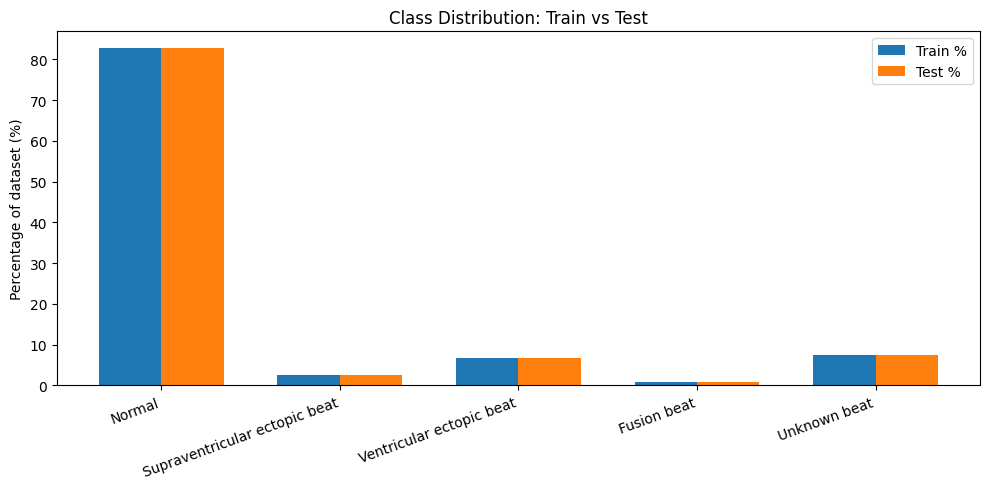

In [3]:
x = np.arange(len(split_summary))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, split_summary["train_pct"], width, label="Train %")
ax.bar(x + width/2, split_summary["test_pct"], width, label="Test %")

ax.set_xticks(x)
ax.set_xticklabels(split_summary["class"], rotation=20, ha="right")
ax.set_ylabel("Percentage of dataset (%)")
ax.set_title("Class Distribution: Train vs Test")
ax.legend()
plt.tight_layout()
plt.show()

**Result:** The chart shows the train and test bars for each class visually overlapping almost perfectly, consistent with the numeric comparison above.

**Interpretation:** This is a visual confirmation, not new evidence — it makes the near-identical per-class proportions easy to communicate, but doesn't change the limitation noted above.

In [4]:
def ordering_report(df, name):
    labels = df[label_col].values
    n = len(labels)
    change_points = np.sum(labels[1:] != labels[:-1])
    n_runs = change_points + 1
    same_next_frac = 1 - (change_points / (n - 1))

    print(f"--- {name} (n={n}) ---")
    print(f"Contiguous runs of identical label: {n_runs} "
          f"(min possible = {df[label_col].nunique()}, max possible = {n})")
    print(f"Fraction of adjacent rows sharing the same label: {same_next_frac:.5f}")

    rows = []
    for c in sorted(df[label_col].unique()):
        idx = np.where(labels == c)[0]
        span = idx.max() - idx.min() + 1
        rows.append({
            "class": class_labels[c], "first_idx": idx.min(), "last_idx": idx.max(),
            "span": span, "count": len(idx), "span/count": round(span / len(idx), 3),
        })
    display(pd.DataFrame(rows))

ordering_report(train_df, "TRAIN")
ordering_report(test_df, "TEST")

--- TRAIN (n=87554) ---
Contiguous runs of identical label: 5 (min possible = 5, max possible = 87554)
Fraction of adjacent rows sharing the same label: 0.99995


,class,first_idx,last_idx,span,count,span/count
0,Normal,0,72470,72471,72471,1.0
1,Supraventricular ectopic beat,72471,74693,2223,2223,1.0
2,Ventricular ectopic beat,74694,80481,5788,5788,1.0
3,Fusion beat,80482,81122,641,641,1.0
4,Unknown beat,81123,87553,6431,6431,1.0


--- TEST (n=21892) ---
Contiguous runs of identical label: 5 (min possible = 5, max possible = 21892)
Fraction of adjacent rows sharing the same label: 0.99982


,class,first_idx,last_idx,span,count,span/count
0,Normal,0,18117,18118,18118,1.0
1,Supraventricular ectopic beat,18118,18673,556,556,1.0
2,Ventricular ectopic beat,18674,20121,1448,1448,1.0
3,Fusion beat,20122,20283,162,162,1.0
4,Unknown beat,20284,21891,1608,1608,1.0


**Result:** In both train and test, the label column shows only 5 contiguous runs — one per class — with over 99.9% of adjacent rows sharing the same label. Per class, `span / count = 1.000` in every case, meaning each class occupies one unbroken block of rows (e.g. in `mitbih_train.csv`, rows 0–72470 are entirely class 0, followed immediately by class 1, and so on).

**Interpretation:** Neither CSV is shuffled — the rows are grouped by class label in file order. This is an observed structural fact, not an assumption.

**Why this matters for future work:**
- **Positional sampling is unsafe.** Any subset taken by row position (e.g. "first N rows for a quick test") would return an almost entirely single-class sample.
- **Unshuffled cross-validation would be invalid.** Scikit-learn's `KFold` defaults to `shuffle=False`; applied directly to these files, each fold would be built from a near-mono-class contiguous block, producing degenerate, uninformative validation folds.
- **Recommendation for later phases:** any splitting or cross-validation performed on this data must either shuffle explicitly (with a fixed random seed for reproducibility) or use a stratified method (e.g. `StratifiedKFold`), given the class imbalance already confirmed here.

## Phase A2 — Duplicate and Leakage Screening

**Objective:** Check whether identical heartbeat samples appear more than once — within a single file, or across the train/test boundary.

**Scientific question:** Does the dataset contain exact duplicate rows, and if so, could any of them cross the train/test split in a way that would leak test information into training?

**Why this matters:** If the same beat appears in both train and test, a model could achieve artificially high test performance simply by memorizing that specific row, rather than by learning generalizable ECG morphology.

In [5]:
train_dup_within = train_df.duplicated(keep=False).sum()
test_dup_within = test_df.duplicated(keep=False).sum()

print(f"Exact duplicate rows within TRAIN: {train_dup_within} ({train_dup_within/len(train_df)*100:.2f}%)")
print(f"Exact duplicate rows within TEST:  {test_dup_within} ({test_dup_within/len(test_df)*100:.2f}%)")

# Cross-set check: hash pre-filter, then verify with an actual row-equality merge
# (hash collisions alone would not be reliable proof of an exact duplicate)
train_hashes = pd.util.hash_pandas_object(train_df, index=False)
test_hashes = pd.util.hash_pandas_object(test_df, index=False)
hash_overlap = test_hashes.isin(set(train_hashes.values))
n_hash_overlap = hash_overlap.sum()

if n_hash_overlap > 0:
    confirmed = test_df[hash_overlap.values].merge(train_df, how="inner")
    n_confirmed = len(confirmed)
else:
    n_confirmed = 0

print(f"TEST rows exactly matching a TRAIN row (hash pre-filter): {n_hash_overlap}")
print(f"Confirmed exact-row duplicates between TRAIN and TEST (verified): {n_confirmed} "
      f"({n_confirmed/len(test_df)*100:.2f}% of test set)")

Exact duplicate rows within TRAIN: 0 (0.00%)
Exact duplicate rows within TEST:  0 (0.00%)
TEST rows exactly matching a TRAIN row (hash pre-filter): 0
Confirmed exact-row duplicates between TRAIN and TEST (verified): 0 (0.00% of test set)


**Result:** No exact duplicate rows were found within train, within test, or across train and test (verified by full-row equality after a hash-based pre-filter, not hash comparison alone — hash collisions were checked against the actual row values).

**Interpretation:** There is no evidence of exact-copy leakage between train and test in these files.

**Why a near-duplicate (similarity-based) analysis is not implemented here:** Detecting *near*-duplicates (e.g. two highly similar but not identical beats) would require choosing a similarity metric and a threshold to decide what counts as "the same underlying beat." Any such threshold would be arbitrary without external ground truth (e.g. knowing which beats come from the same patient recording) to calibrate it — so it was intentionally left out rather than implemented on an unjustified cutoff.

**Limitation — this is important:** These CSV files contain **no patient or recording identifier**. The original MIT-BIH database consists of a limited number of long recordings from a limited number of patients, and consecutive beats from the same patient are known to be highly similar to each other. Because of this:
- The absence of exact duplicates **does not prove** the split is free of leakage.
- Near-duplicate, same-patient beats could still be split across train and test without being caught by exact matching.
- Patient-level independence between train and test **cannot be verified from these CSV files alone.**

## Phase A3 — Value Range and Data Integrity

**Objective:** Confirm that the dataset is numerically clean and that its values fall within the range implied by the documented preprocessing (per-beat min-max normalization) before any further work is done.

**Scientific question:** Are there missing, infinite, non-numeric, or out-of-range values in either file, and are the two files schema-compatible?

**Why this matters:** Any preprocessing or modeling decision made on top of unverified data risks building on a false assumption (e.g. assuming no missing values, or assuming a [0,1] range for a scaler) that later causes silent errors.

In [6]:
print("Missing values")
for name, df in [("TRAIN", train_df), ("TEST", test_df)]:
    print(f"  {name}: total NaN cells = {df.isna().sum().sum()}")

print("\nInfinite values")
for name, df in [("TRAIN", train_df), ("TEST", test_df)]:
    print(f"  {name}: infinite cells = {np.isinf(df.values).sum()}")

print("\nDtypes / non-numeric columns")
for name, df in [("TRAIN", train_df), ("TEST", test_df)]:
    non_numeric = df.select_dtypes(exclude=[np.number]).columns.tolist()
    print(f"  {name}: unique dtypes = {list(df.dtypes.unique())}, non-numeric columns = {non_numeric}")

print("\nSchema compatibility")
print(f"  Train shape: {train_df.shape}   Test shape: {test_df.shape}")
print(f"  Same number of columns: {train_df.shape[1] == test_df.shape[1]}")
print(f"  Columns with dtype mismatch: {(train_df.dtypes.values != test_df.dtypes.values).sum()}")

Missing values


  TRAIN: total NaN cells = 0
  TEST: total NaN cells = 0

Infinite values
  TRAIN: infinite cells = 0
  TEST: infinite cells = 0

Dtypes / non-numeric columns
  TRAIN: unique dtypes = [dtype('float64')], non-numeric columns = []
  TEST: unique dtypes = [dtype('float64')], non-numeric columns = []

Schema compatibility
  Train shape: (87554, 188)   Test shape: (21892, 188)
  Same number of columns: True
  Columns with dtype mismatch: 0


In [7]:
print("ECG feature value range (columns 0-186, label excluded)")
for name, df in [("TRAIN", train_df), ("TEST", test_df)]:
    feat = df[feature_cols]
    below0 = (feat < 0).values.sum()
    above1 = (feat > 1).values.sum()
    print(f"  {name}: min={feat.values.min():.6f}, max={feat.values.max():.6f}, "
          f"values<0: {below0}, values>1: {above1}")

print("\nLabel column integrity (column 187)")
expected_labels = set(class_labels.keys())
for name, df in [("TRAIN", train_df), ("TEST", test_df)]:
    observed = set(df[label_col].unique())
    unexpected = observed - expected_labels
    print(f"  {name}: observed labels = {sorted(observed)}, unexpected labels = {sorted(unexpected)}")

ECG feature value range (columns 0-186, label excluded)


  TRAIN: min=0.000000, max=1.000000, values<0: 0, values>1: 0


  TEST: min=0.000000, max=1.000000, values<0: 0, values>1: 0

Label column integrity (column 187)
  TRAIN: observed labels = [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)], unexpected labels = []
  TEST: observed labels = [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)], unexpected labels = []


In [8]:
print("Flatline / zero-variance rows (feature columns only)")
for name, df in [("TRAIN", train_df), ("TEST", test_df)]:
    feat = df[feature_cols]
    all_zero = (feat == 0).all(axis=1).sum()
    zero_variance = (feat.std(axis=1) == 0).sum()
    print(f"  {name}: all-zero rows = {all_zero}, zero-variance rows = {zero_variance}")

Flatline / zero-variance rows (feature columns only)


  TRAIN: all-zero rows = 0, zero-variance rows = 0
  TEST: all-zero rows = 0, zero-variance rows = 0


**Results:**
- No missing values, no infinite values, and no non-numeric columns in either file — both are pure `float64` across all 188 columns.
- Train and test have identical shape structure (188 columns each) and identical dtypes column-for-column.
- All 187 ECG feature values fall within [0, 1] in both files, with zero values below 0 or above 1.
- Both files contain only the five expected label values {0, 1, 2, 3, 4} — no unexpected classes.
- No flatline (all-zero) or zero-variance rows in either file.

**Interpretation:** On every check performed here, the dataset is internally consistent and clean. The [0,1] range is consistent with per-beat min-max normalization having already been applied by whoever produced these CSV files.

**Limitation — scope of this conclusion:** These checks confirm that the data is *internally* clean and within an expected numeric range; they do **not** by themselves establish that no further normalization or scaling will ever be needed later in the pipeline. That depends on decisions not yet made (e.g. how features are engineered, which model family is chosen, whether the two datasets are combined with others such as PTBDB). This section states only what current evidence supports — the absence of a *currently visible* integrity problem — not a guarantee about future preprocessing requirements.

## Phase A — Summary

**Facts established directly from the data:**
- The train/test split preserves per-class proportions to within ~0.02 percentage points for every class.
- Both CSV files are ordered (block-sorted) by class label, not shuffled.
- No exact duplicate rows exist within or across train/test.
- No missing, infinite, non-numeric, or out-of-range values exist in either file; schemas match.

**Interpretations built on those facts:**
- The split was very likely constructed with explicit stratification by class.
- Any future sampling, splitting, or cross-validation on this data must shuffle explicitly and account for class imbalance.

**Documented limitations (explicitly not resolved by this notebook):**
- Patient/record-level independence between train and test cannot be verified — no patient identifiers exist in these files, and exact-duplicate absence does not rule out near-duplicate, same-patient leakage.
- Data integrity checks confirm the *current* state is clean; they do not guarantee no normalization will be needed once feature engineering or model-specific preprocessing begins.

**Next steps (deferred to a later notebook/phase):**
- Zero-padding and effective signal length analysis.
- Any preprocessing or model training — intentionally not started here.